#📝 TASK 2 — Classification

Problem Statement

Predict whether a breast tumor is malignant or benign using medical diagnostic features.

Breast Cancer Wisconsin Diagnostic Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# 1. Load Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nFirst 5 rows:")
print(X.head())

# 2. Explore Dataset
print("\nDataset Information:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nTarget Distribution:")
print(y.value_counts())

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================

logistic_model = LogisticRegression(max_iter=5000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

# ============================================
# MODEL 2: DECISION TREE
# ============================================

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

# ============================================
# EVALUATION
# ============================================

log_accuracy = accuracy_score(y_test, y_pred_logistic)
log_precision = precision_score(y_test, y_pred_logistic)
log_recall = recall_score(y_test, y_pred_logistic)

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)

print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\n===== DECISION TREE =====")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

# ============================================
# MODEL COMPARISON
# ============================================

classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [log_accuracy, tree_accuracy],
    "Precision": [log_precision, tree_precision],
    "Recall": [log_recall, tree_recall]
})

print("\n===== MODEL COMPARISON =====")
print(classification_results)

Dataset Shape: (569, 30)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst 

#📊 Classification Visualization

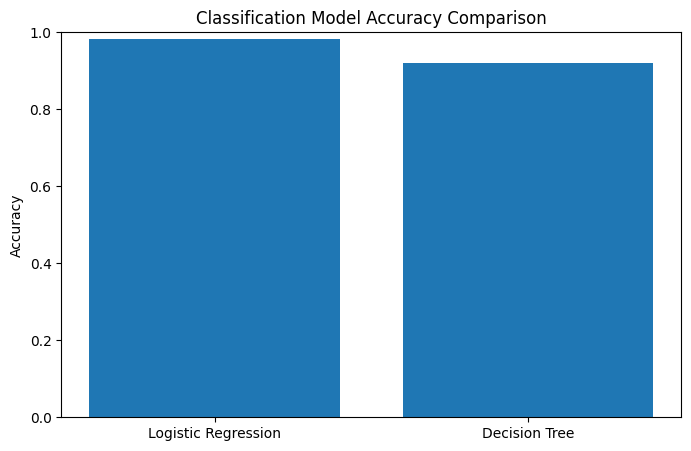

In [3]:
# Accuracy Comparison

models = ["Logistic Regression", "Decision Tree"]
accuracy = [log_accuracy, tree_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Classification Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

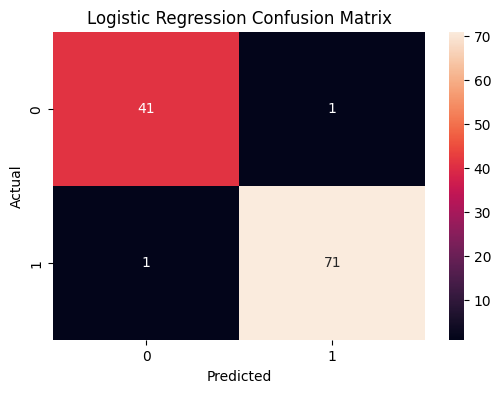

In [4]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_logistic),
    annot=True,
    fmt="d"
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#📝 TASK 3 — Regression

Problem Statement:-

Predict the median house value based on housing-related features.

.

.

.



Dataset:-

California Housing Dataset

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Dataset
data = fetch_california_housing(as_frame=True)

df = data.frame

print("Dataset Shape:", df.shape)
print(df.head())

# 2. Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# 3. Features and Target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 5. Train Linear Regression
model = LinearRegression()

model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== REGRESSION RESULTS =====")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

# 8. Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(results.head(10))

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

===== REGRESSION RESULTS =====
MAE : 0.5332001304956553
MSE : 0.5558915986952444
RMSE: 0.7455813830127764
R²  : 0.5757877060324508

Actual vs Predicted:
    Actual  

#📈 Regression Visualization

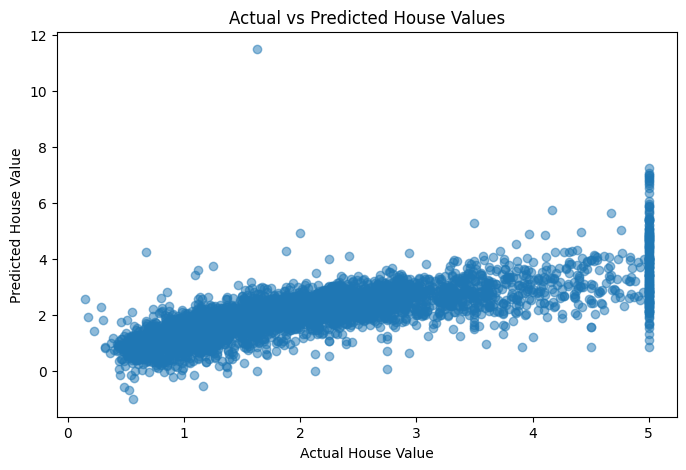

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

#📝 TASK 4 — Model Evaluation & Comparison

Model:- Classification

Use:

Accuracy

Precision

Recall

Confusion Matrix

Which model is better?

Choose the model having the better overall evaluation metrics, especially recall for medical classification.

.

.

.

Why?

Logistic Regression often performs strongly on this dataset because the features provide good separation between the two classes.

.

.

.

Limitations:-

The model is trained on a specific dataset and may not generalize perfectly to patients from different populations or hospitals.

| Metric   | Meaning                                      |
| -------- | -------------------------------------------- |
| **MAE**  | Average absolute prediction error            |
| **MSE**  | Average squared prediction error             |
| **RMSE** | Square root of MSE                           |
| **R²**   | How well the model explains target variation |


For regression:

Lower MAE/MSE/RMSE = better

Higher R² = better

#📝 TASK 5 — MINI PROJECT

##Project Title:-
Breast Cancer Classification Using Machine Learning

##Problem:-

Early identification of breast cancer can help support medical diagnosis. The objective of this project is to develop machine learning models that classify tumors as malignant or benign based on diagnostic measurements.

Problem Definition

        ↓

Dataset Collection

        ↓

Data Exploration

        ↓

Data Cleaning

        ↓

Feature Selection

        ↓

Train/Test Split

        ↓

Feature Scaling

        ↓

Logistic Regression

        ↓

Decision Tree

        ↓

Predictions

        ↓

Evaluation

        ↓

Model Comparison

        ↓
        
Conclusion

##Visualization 1 — Target Distribution

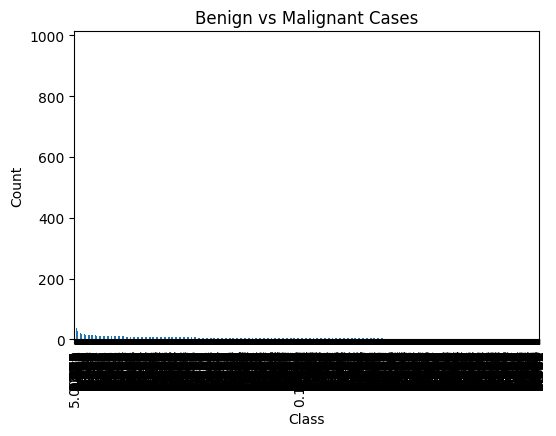

In [7]:
plt.figure(figsize=(6,4))
y.value_counts().plot(kind="bar")
plt.title("Benign vs Malignant Cases")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

##Visualization 2 — Model Accuracy

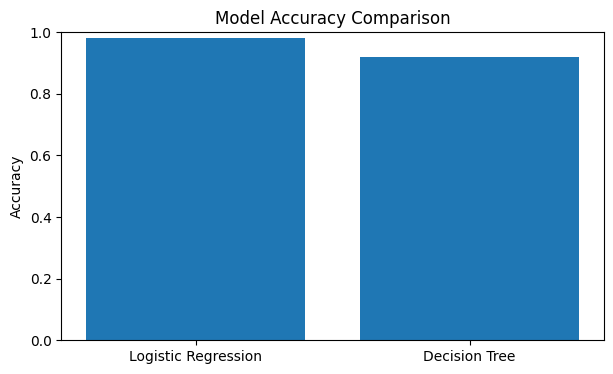

In [9]:
plt.figure(figsize=(7,4))

plt.bar(
    ["Logistic Regression", "Decision Tree"],
    [log_accuracy, tree_accuracy]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

##Visualization 3 — Confusion Matrix

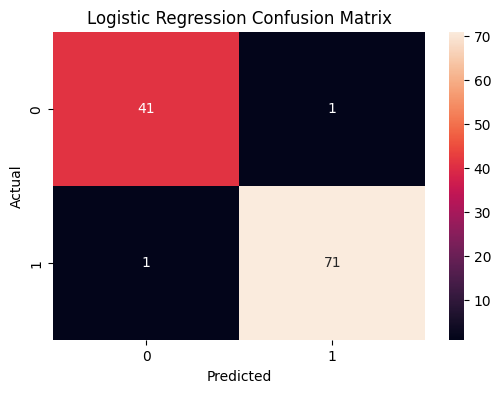

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd # Import pandas if not already in the cell

# Load the Breast Cancer dataset (X and y were overwritten by California Housing data)
data_clf = load_breast_cancer()
X_clf = pd.DataFrame(data_clf.data, columns=data_clf.feature_names)
y_clf = pd.Series(data_clf.target, name="target")

# Recreate Breast Cancer test data using the *correct* classification data
# Note: X_train_c, X_test_c, y_train_c, y_test_c are new variables, avoiding conflict with global X, y
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf # Stratify on the classification target
)

# Scale the data for Logistic Regression.
# The 'scaler' object is global and was fitted on the original breast cancer data.
X_test_c_scaled = scaler.transform(X_test_c)

# Make predictions using the 'logistic_model' (also global and trained on breast cancer data).
y_pred_logistic = logistic_model.predict(X_test_c_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_logistic)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()